# LightSB-M on MNIST — Latent-Space

In [ ]:
import sys
sys.path.append('..')

import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm

import copy
import matplotlib.pyplot as plt
import math, time
import pandas as pd
import random

from torchvision import datasets

from src.lightsbm_vm_v1 import LightSBM

torch.manual_seed(0)
torch.set_num_threads(4)          
device = torch.device("cpu")
print(torch.__version__)

2.12.1+cu130


## 1. Data + PCA encoder/decoder

Whitened latents ($z$ has unit variance per component) so a $\mathcal N(0,I)$ source and
`S_diagonal_init=0.1` are well-scaled without further tuning.

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = torch.tensor(mnist.data, dtype=torch.float32).div(255.).mul(2).sub(1)  
X = X[torch.randperm(len(X))[:20_000]]

d_lat = 150
mean = X.mean(0)
Xc = X - mean
U, S, Vt = torch.linalg.svd(Xc, full_matrices=False)
V = Vt[:d_lat].T                                  
scale = S[:d_lat] / math.sqrt(len(X))             

encode = lambda x: ((x - mean) @ V) / scale       # image ->  latent
decode = lambda z: (z * scale) @ V.T + mean       # latent -> image

Z = encode(X)
evr = (S[:d_lat]**2).sum() / (S**2).sum()
print(f"latents {tuple(Z.shape)}, explained variance {evr:.1%}")

latents (20000, 150), explained variance 94.9%


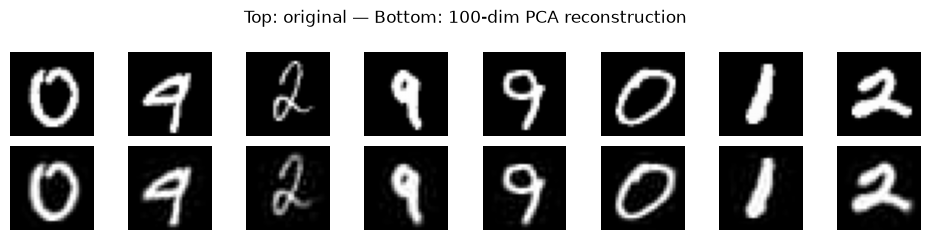

In [4]:
def show_grid(imgs, n_row, n_col, title=None):
    imgs = imgs.detach().reshape(-1, 28, 28)
    fig, axes = plt.subplots(n_row, n_col, figsize=(n_col*1.2, n_row*1.2))
    for ax, im in zip(axes.flat, imgs):
        ax.imshow(im.clamp(-1,1)*0.5+0.5, cmap="gray", vmin=0, vmax=1); ax.axis("off")
    if title: fig.suptitle(title)
    plt.tight_layout(); plt.show()

show_grid(torch.cat([X[:8], decode(Z[:8])]), 2, 8,
          "Top: original — Bottom: 100-dim PCA reconstruction")


## Part A — Unpaired translation: digit 3 → digit 8 (latent space)


In [ ]:
K, EPS, T_H = 250, 0.1, 1
N_ITERS, BATCH = 3000, 512
SRC, TGT = 3, 8

from torchvision import datasets
mnist_tv = datasets.MNIST(root="./data", train=True, download=True)
X_all = mnist_tv.data.float().div(255.).mul(2).sub(1).reshape(-1, 784)
y_all = mnist_tv.targets

seed = 21
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

perm = torch.randperm(len(X_all))[:20_000]
X, y = X_all[perm], y_all[perm]

X_src, X_tgt = X[y == SRC], X[y == TGT]
Z_src, Z_tgt = encode(X_src), encode(X_tgt)    
print(f"{len(Z_src)} images of {SRC},  {len(Z_tgt)} images of {TGT}")

2028 images of 3,  1947 images of 8


In [ ]:
tr_model = LightSBM(dim=d_lat, n_potentials=K, epsilon=EPS, T=T_H,
                    is_diagonal=True, S_diagonal_init=0.1)
tr_model.init_mu_by_samples(Z_tgt[torch.randperm(len(Z_tgt))[:K]])

opt = torch.optim.Adam(tr_model.parameters(), lr=1e-3)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_ITERS, eta_min=1e-4)

best_loss = float('inf')
best_state = None
best_iter = 0
no_improve_count = 0
losses, t0 = [], time.time()

for it in range(1, N_ITERS + 1):
    x0 = Z_src[torch.randint(0, len(Z_src), (BATCH,))]
    x1 = Z_tgt[torch.randint(0, len(Z_tgt), (BATCH,))]
    t = torch.rand(BATCH) * T_H * 0.99
    xt = (1 - t[:, None]/T_H)*x0 + (t[:, None]/T_H)*x1 \
         + torch.sqrt(EPS*t*(T_H - t)/T_H)[:, None]*torch.randn(BATCH, d_lat)
    loss = ((tr_model.get_drift(xt, t) - (x1 - xt)/(T_H - t)[:, None])**2).mean()
    opt.zero_grad(); loss.backward(); opt.step(); sch.step()

    if not torch.isfinite(loss):
        print(f"diverged at {it}"); break

    losses.append(loss.item())

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_iter = it
        best_state = {k: v.clone() for k, v in tr_model.state_dict().items()}

    if it % 200 == 0:
        print(f"iter {it:5d} | loss {loss.item():8.4f} | best {best_loss:8.4f} @ iter {best_iter}")

        if best_iter <= (it - 200):
            no_improve_count += 1
        else:
            no_improve_count = 0

        if no_improve_count >= 2:
            print(f"\nEarly stopping — best loss {best_loss:.4f} @ iter {best_iter} unchanged for 2 checkpoints")
            break

runtime = time.time() - t0
tr_model.load_state_dict(best_state)
print(f"\nRestored model from iter {best_iter} with loss {best_loss:.4f}")
print(f"Total runtime: {runtime:.1f}s ({runtime/60:.1f} min)")

iter   200 | loss  10.8784 | best   8.9728 @ iter 69
iter   400 | loss  11.1667 | best   8.2661 @ iter 220
iter   600 | loss  10.1059 | best   8.2661 @ iter 220
iter   800 | loss  10.3785 | best   8.2661 @ iter 220

Early stopping — best loss 8.2661 @ iter 220 unchanged for 2 checkpoints

Restored model from iter 220 with loss 8.2661
Total runtime: 284.5s (4.7 min)


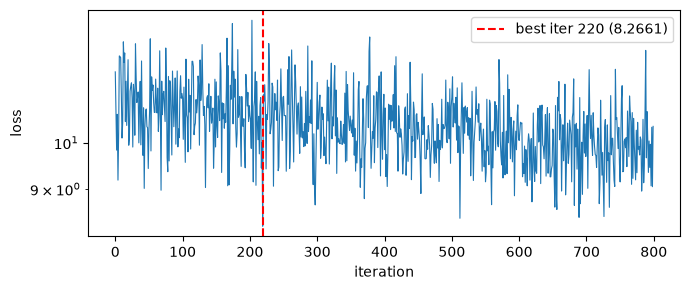

In [7]:
plt.figure(figsize=(7, 3))
plt.plot(losses, lw=0.8)
plt.axvline(best_iter - 1, color='red', ls='--', label=f'best iter {best_iter} ({best_loss:.4f})')
plt.yscale('log'); plt.xlabel('iteration'); plt.ylabel('loss')
plt.legend(); plt.tight_layout(); plt.show()

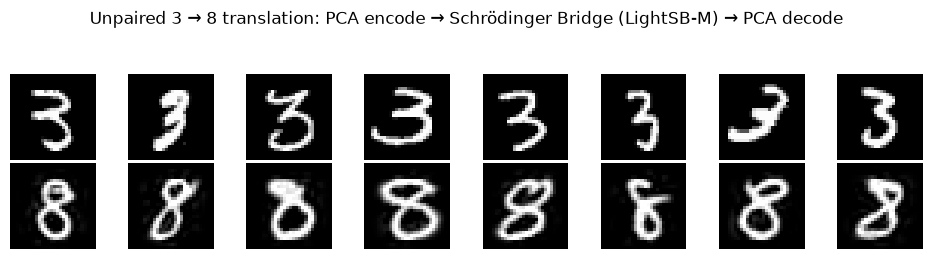

In [ ]:
with torch.no_grad():
    x_in  = X_src[:8]
    x_out = decode(tr_model(encode(x_in))).clamp(-1, 1)

fig, axes = plt.subplots(2, 8, figsize=(9.6, 2.6))
for j in range(8):
    axes[0, j].imshow(x_in[j].reshape(28, 28)*0.5+0.5,  cmap="gray", vmin=0, vmax=1)
    axes[1, j].imshow(x_out[j].reshape(28, 28)*0.5+0.5, cmap="gray", vmin=0, vmax=1)
    axes[0, j].axis("off"); axes[1, j].axis("off")
fig.suptitle(
    f"Unpaired {SRC} → {TGT} translation: PCA encode → Schrödinger Bridge (LightSB-M) → PCA decode\n"
)
plt.tight_layout(); plt.show()

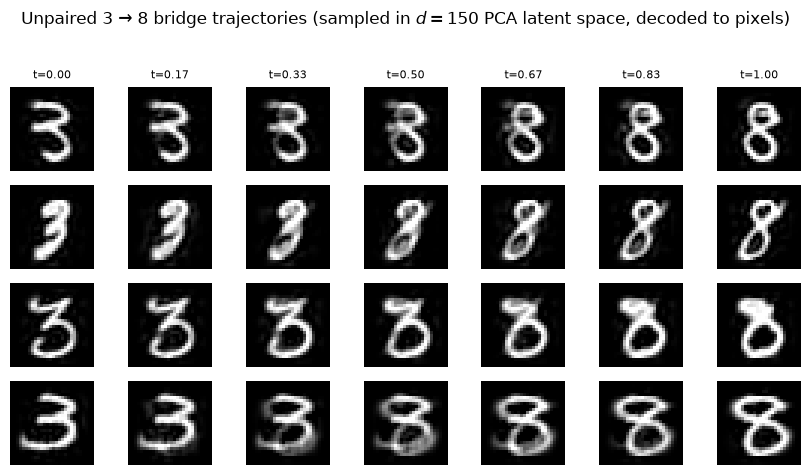

In [17]:
# Bridge Trajectory Sampling: watch no.3 turns into no.8
with torch.no_grad():
    traj = tr_model.sample_bridge_trajectory(Z_src[:4], n_steps=6)  
n_show, n_steps = traj.shape[0], traj.shape[1]
fig, axes = plt.subplots(n_show, n_steps, figsize=(n_steps*1.2, n_show*1.2))
for i in range(n_show):
    for j in range(n_steps):
        img = decode(traj[i, j][None]).reshape(28, 28).clamp(-1, 1) * 0.5 + 0.5
        axes[i, j].imshow(img, cmap="gray", vmin=0, vmax=1); axes[i, j].axis("off")
        if i == 0: axes[i, j].set_title(f"t={j/(n_steps-1):.2f}", fontsize=8)
fig.suptitle(f"Unpaired {SRC} → {TGT} bridge trajectories (sampled in $d={d_lat}$ PCA latent space, decoded to pixels)\n")
plt.tight_layout(); plt.show()